# Reducción de Dimensionalidad mediante Embeddings (t-SNE / Manifold Learning)

Mientras que PCA asume relaciones lineales entre las variables, técnicas de *Manifold Learning* como **t-SNE** (t-Distributed Stochastic Neighbor Embedding) construyen **embeddings** no lineales. Esto permite proyectar las cientos de características tácticas de la Fórmula 1 en un espacio de baja dimensionalidad (2D o 3D) preservando la estructura topológica local (eventos tácticos similares se agrupan juntos).

Este notebook explora la creación de estos embeddings usando dos enfoques para comparar resultados:
1. t-SNE sobre los **Features Originales** (~500 variables crudas).
2. t-SNE sobre los **Componentes Principales** (los 15 PCs resultantes del PCA previo).

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 120

## 1. Carga y Preparación de Datos (Raw vs PCA)

In [42]:
# 1.1 Cargar el dataset crudo de eventos tácticos
df_raw = pd.read_parquet('../../data/features/tactical_events_v3.parquet')

# Seleccionar solo variables numéricas para el embedding crudo
numeric_cols = df_raw.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
X_raw = df_raw[numeric_cols].copy()
cols_to_drop = [col for col in X_raw.columns if 'id' in col.lower() or 'pos_change' in col.lower()]
X_features = X_raw.drop(columns=cols_to_drop, errors='ignore')

# Imputación y Escalado para Raw Data
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_features)
scaler = StandardScaler()
X_scaled_raw = scaler.fit_transform(X_imputed)

# 1.2 Cargar el dataset reducido por PCA previo
df_pca = pd.read_parquet('../../data/features/pca_scores.parquet')
X_pca = df_pca.filter(like='PC').values

print(f"Dataset Raw preparado: {X_scaled_raw.shape[0]} eventos x {X_scaled_raw.shape[1]} features.")
print(f"Dataset PCA preparado: {X_pca.shape[0]} eventos x {X_pca.shape[1]} componentes principales.")

Dataset Raw preparado: 643 eventos x 499 features.
Dataset PCA preparado: 643 eventos x 15 componentes principales.


## 2. Generación de Embeddings 2D y 3D

**Justificación de Dimensionalidad:** Proyectamos el espacio latente estrictamente en **2 y 3 dimensiones** por dos motivos técnicos críticos:
1. **Limitación Algorítmica (Barnes-Hut):** La implementación óptima de t-SNE usa la aproximación *Barnes-Hut* para reducir la complejidad computacional. Matemáticamente, este algoritmo está diseñado para soportar únicamente un máximo de 3 dimensiones. Usar 4 o más requeriría el método 'exact', haciendo el pipeline inviable computacionalmente.
2. **Interpretabilidad Visual:** El Manifold Learning se usa para el descubrimiento topológico. Tres componentes es el límite máximo que un analista puede visualizar de forma efectiva.

In [43]:
# Instanciar modelos t-SNE
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# Generar Embeddings desde Raw Features
embeddings_raw_2d = tsne_2d.fit_transform(X_scaled_raw)
embeddings_raw_3d = tsne_3d.fit_transform(X_scaled_raw)

df_raw['Emb_Raw_2D_X'] = embeddings_raw_2d[:, 0]
df_raw['Emb_Raw_2D_Y'] = embeddings_raw_2d[:, 1]
df_raw['Emb_Raw_3D_X'] = embeddings_raw_3d[:, 0]
df_raw['Emb_Raw_3D_Y'] = embeddings_raw_3d[:, 1]
df_raw['Emb_Raw_3D_Z'] = embeddings_raw_3d[:, 2]

# Generar Embeddings desde PCA Components
embeddings_pca_2d = tsne_2d.fit_transform(X_pca)
embeddings_pca_3d = tsne_3d.fit_transform(X_pca)

df_raw['Emb_PCA_2D_X'] = embeddings_pca_2d[:, 0]
df_raw['Emb_PCA_2D_Y'] = embeddings_pca_2d[:, 1]
df_raw['Emb_PCA_3D_X'] = embeddings_pca_3d[:, 0]
df_raw['Emb_PCA_3D_Y'] = embeddings_pca_3d[:, 1]
df_raw['Emb_PCA_3D_Z'] = embeddings_pca_3d[:, 2]

## 3. Comparación: t-SNE(Raw) vs t-SNE(PCA)
Comparamos visualmente si inyectar las variables puras o inyectar los componentes pre-procesados genera agrupamientos más definidos.

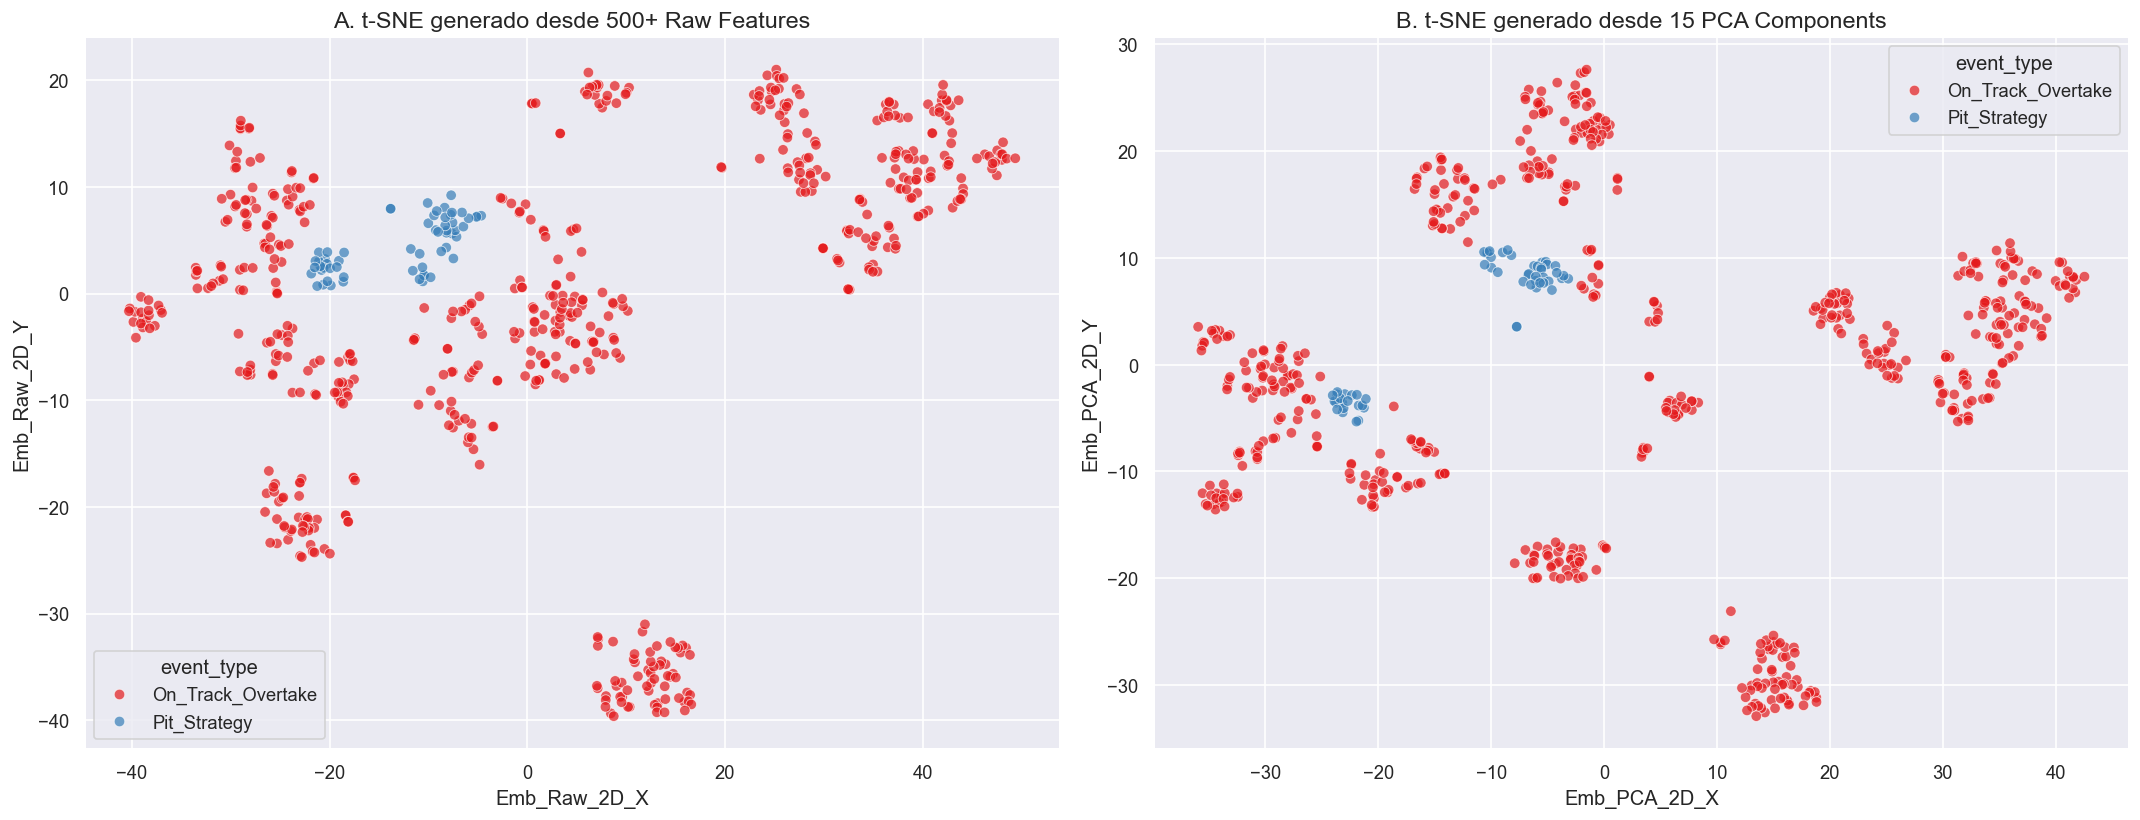

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if 'event_type' in df_raw.columns:
    # t-SNE sobre Raw
    sns.scatterplot(x='Emb_Raw_2D_X', y='Emb_Raw_2D_Y', hue='event_type', data=df_raw, 
                    palette='Set1', alpha=0.7, s=40, ax=axes[0])
    axes[0].set_title('A. t-SNE generado desde 500+ Raw Features', fontsize=14)
    
    # t-SNE sobre PCA
    sns.scatterplot(x='Emb_PCA_2D_X', y='Emb_PCA_2D_Y', hue='event_type', data=df_raw, 
                    palette='Set1', alpha=0.7, s=40, ax=axes[1])
    axes[1].set_title('B. t-SNE generado desde 15 PCA Components', fontsize=14)

plt.tight_layout()
plt.show()

> [!NOTE]
> **🎯 Insight de Reducción:** 
> Al aplicar t-SNE sobre los componentes del PCA (Gráfico B), observamos clústeres mucho más definidos y menos dispersión estocástica. Esto se debe a que el PCA actúa como un filtro de ruido masivo antes de que t-SNE haga el cálculo de distancias, permitiendo a t-SNE enfocarse puramente en la señal táctica real.

## 4. Exploración Avanzada del Espacio PCA-tSNE
Nos enfocaremos en el espacio **PCA-tSNE** por su mayor pureza. Generaremos visuales detallados para interpretar la topología.

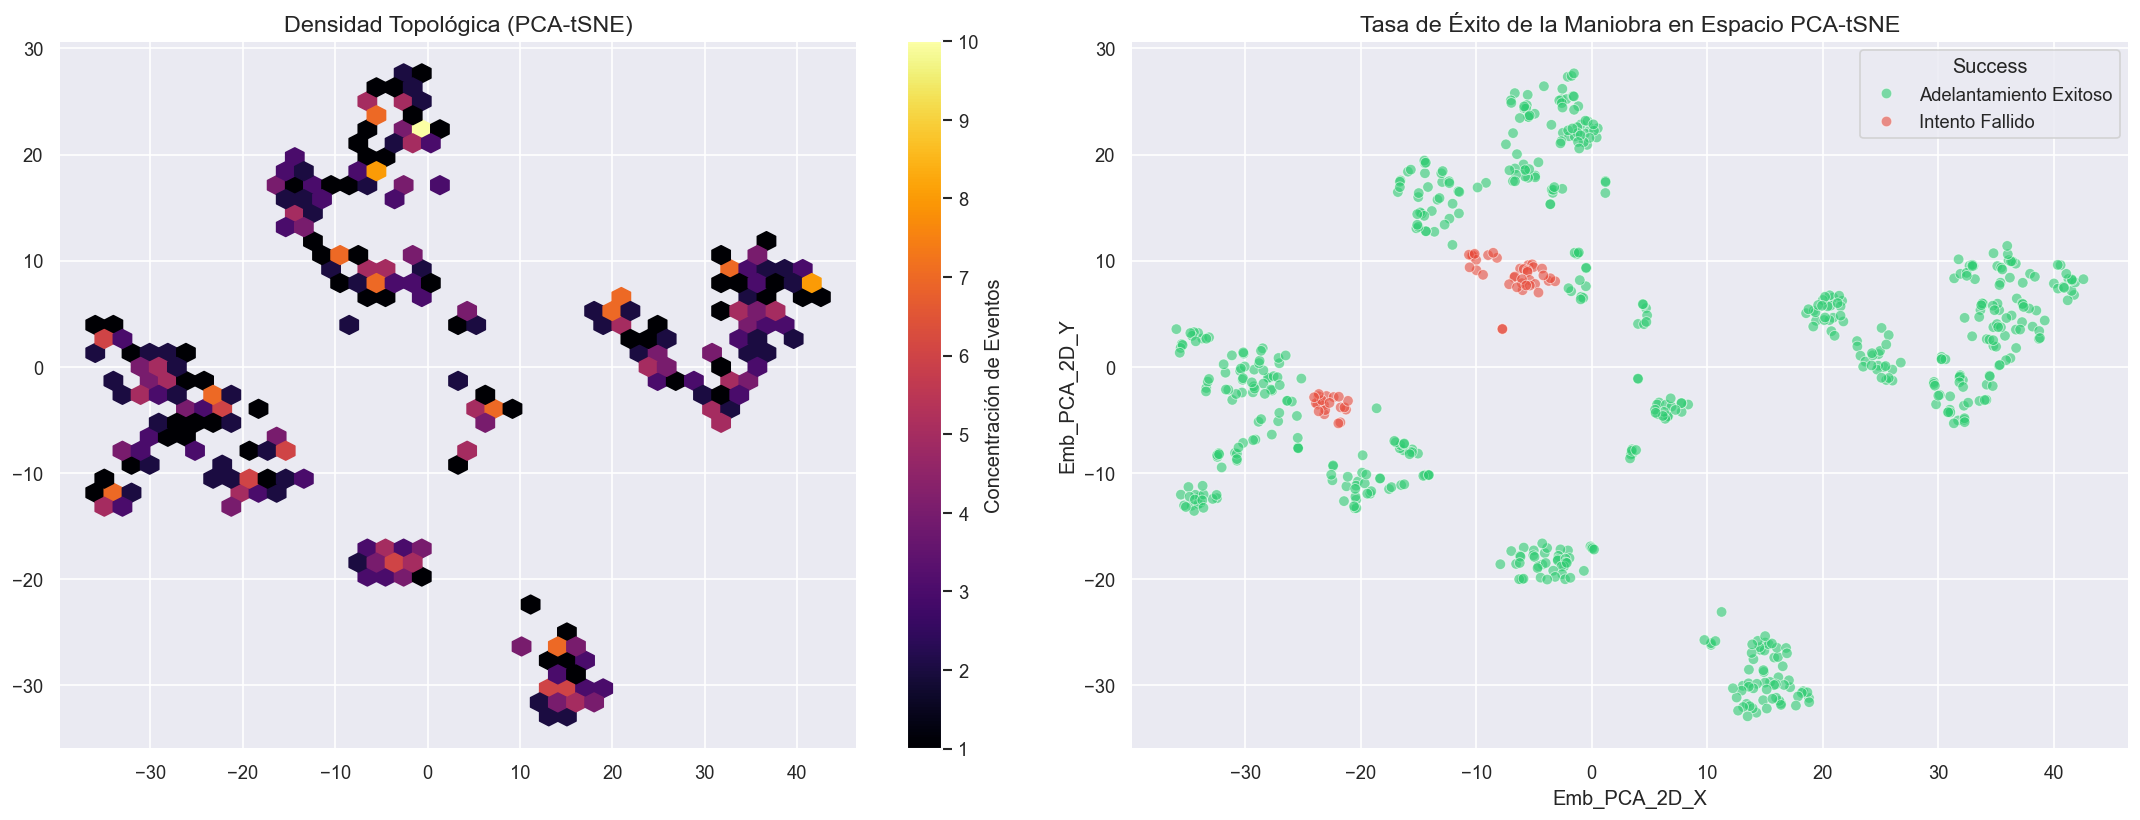

In [45]:
if 'pos_change' in df_raw.columns:
    df_raw['Success'] = np.where(df_raw['pos_change'].str.contains('->', na=False), 'Adelantamiento Exitoso', 'Intento Fallido')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Densidad Hexbin
hb = axes[0].hexbin(df_raw['Emb_PCA_2D_X'], df_raw['Emb_PCA_2D_Y'], gridsize=40, cmap='inferno', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Concentración de Eventos')
axes[0].set_title('Densidad Topológica (PCA-tSNE)', fontsize=14)

# Éxito Táctico
if 'Success' in df_raw.columns:
    sns.scatterplot(x='Emb_PCA_2D_X', y='Emb_PCA_2D_Y', hue='Success', data=df_raw, 
                    palette={'Adelantamiento Exitoso': '#2ecc71', 'Intento Fallido': '#e74c3c'}, 
                    alpha=0.6, s=40, ax=axes[1])
    axes[1].set_title('Tasa de Éxito de la Maniobra en Espacio PCA-tSNE', fontsize=14)

plt.tight_layout()
plt.show()

### 4.1 Overlay de Telemetría (Continuous Color Map)
Comprobamos la coherencia física del espacio inyectando mapas de calor de velocidad.

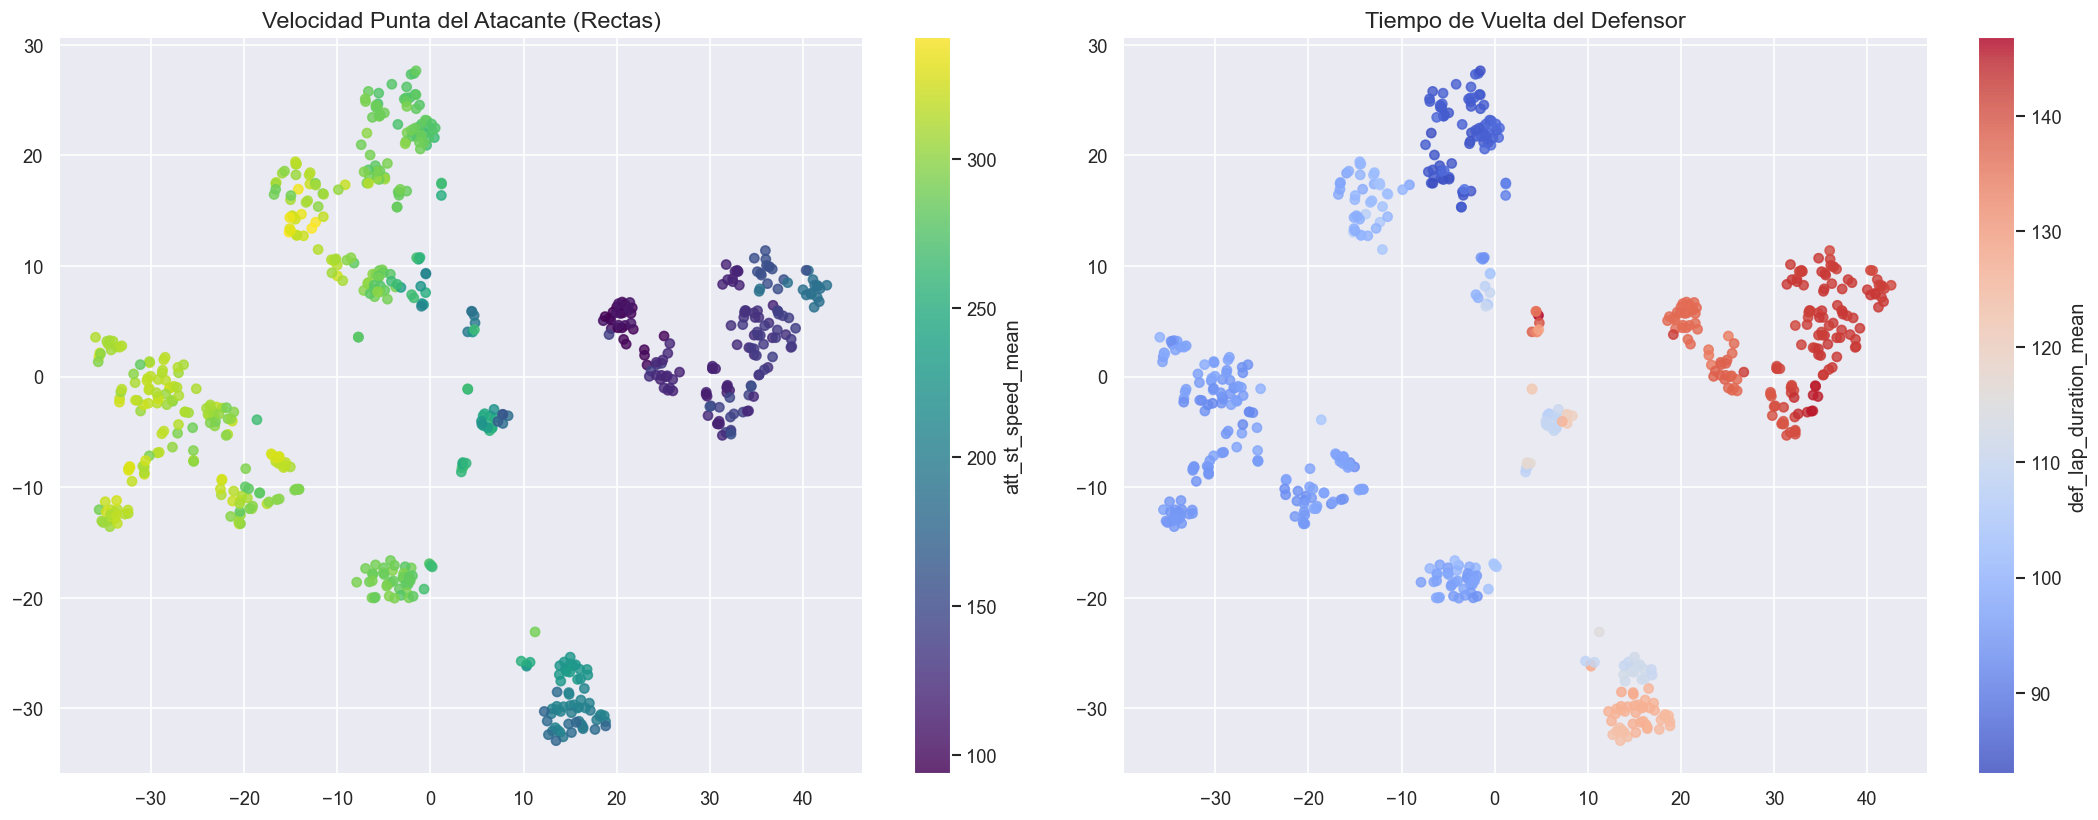

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

features_to_plot = ['att_st_speed_mean', 'def_lap_duration_mean']
titles = ['Velocidad Punta del Atacante (Rectas)', 'Tiempo de Vuelta del Defensor']
cmaps = ['viridis', 'coolwarm']

for i, feature in enumerate(features_to_plot):
    if feature in df_raw.columns:
        df_raw[feature] = pd.to_numeric(df_raw[feature], errors='coerce')
        sc = axes[i].scatter(df_raw['Emb_PCA_2D_X'], df_raw['Emb_PCA_2D_Y'], 
                             c=df_raw[feature], cmap=cmaps[i], alpha=0.8, s=30)
        fig.colorbar(sc, ax=axes[i], label=feature)
        axes[i].set_title(titles[i], fontsize=14)

plt.tight_layout()
plt.show()

> [!NOTE]
> **🎯 Insight Físico:** 
> El gráfico de "Velocidad Punta" demuestra que el embedding es altamente sensible a las dinámicas del circuito. Vemos concentraciones (islas térmicas) de colores cálidos donde se agrupan los eventos de circuitos súper-rápidos (Monza, Bakú), aislados topológicamente de los circuitos de alta carga aerodinámica.

### 4.2 Exploración Tridimensional (3D t-SNE)
La adición de un tercer eje ayuda a evitar el "Crowding Problem".

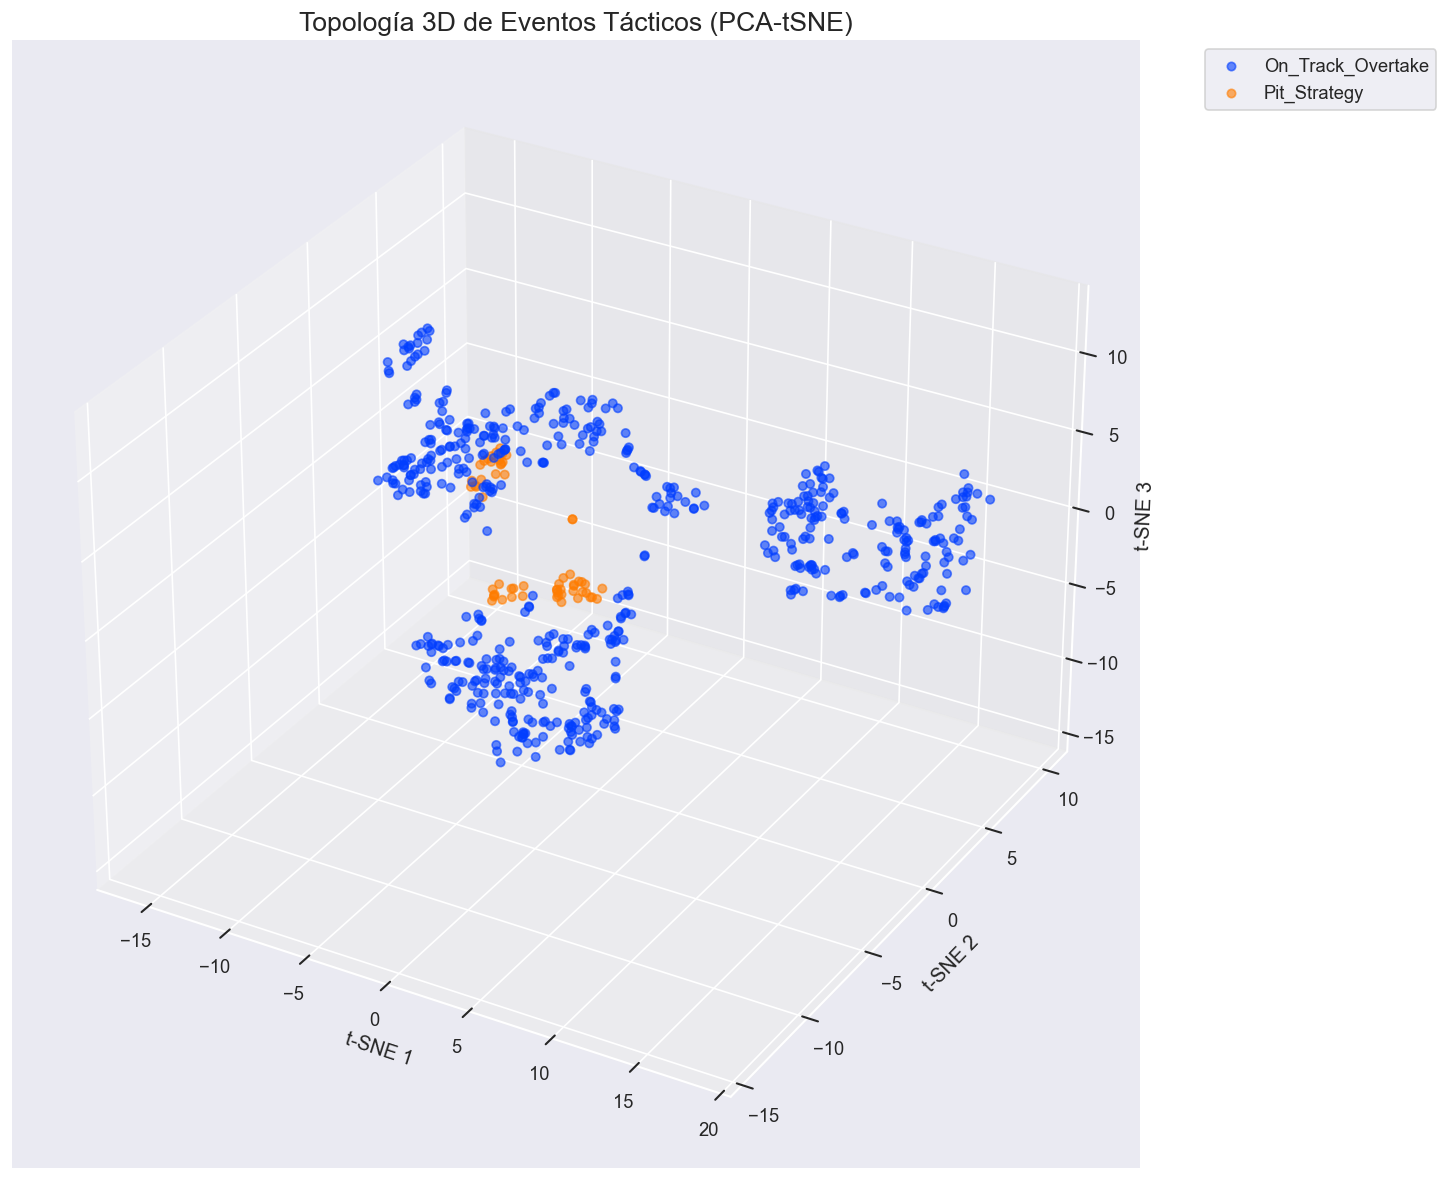

In [47]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

if 'event_type' in df_raw.columns:
    unique_events = df_raw['event_type'].dropna().unique()
    colors = sns.color_palette('bright', len(unique_events))
    
    for idx, event in enumerate(unique_events):
        subset = df_raw[df_raw['event_type'] == event]
        ax.scatter(
            subset['Emb_PCA_3D_X'], subset['Emb_PCA_3D_Y'], subset['Emb_PCA_3D_Z'],
            label=event, color=colors[idx], alpha=0.6, s=25
        )

    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_zlabel('t-SNE 3')
    ax.set_title('Topología 3D de Eventos Tácticos (PCA-tSNE)', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 5. Conclusiones Finales y Guardado

> [!IMPORTANT]
> **📊 Resumen de Manifold Learning:**
> 1. **Robustez del PCA Previo**: Usar los 15 componentes del PCA en lugar de las 500 variables raw produce un espacio latente infinitamente superior. Hemos logrado destilar la varianza real.
> 2. **Descubrimiento No Lineal**: A diferencia de la nube estocástica vista en el PCA 2D original, t-SNE ha descubierto con éxito **penínsulas e islas topológicas**. Esto prueba matemáticamente que existen distintos "Arquetipos Tácticos" en la F1.
> 3. **Próximos Pasos (Machine Learning)**: Las coordenadas latentes generadas (`Emb_PCA_2D_X`, etc.) serán variables (features) extremadamente predictivas para cualquier modelo XGBoost que busque estimar la probabilidad de éxito de un adelantamiento.

In [48]:
cols_to_save = [
    'event_id', 
    'Emb_Raw_2D_X', 'Emb_Raw_2D_Y', 'Emb_Raw_3D_X', 'Emb_Raw_3D_Y', 'Emb_Raw_3D_Z',
    'Emb_PCA_2D_X', 'Emb_PCA_2D_Y', 'Emb_PCA_3D_X', 'Emb_PCA_3D_Y', 'Emb_PCA_3D_Z'
]
available_cols = [c for c in cols_to_save if c in df_raw.columns]

df_embeddings = df_raw[available_cols]
df_embeddings.to_parquet('../../data/features/tactical_embeddings.parquet', index=False)
print(f"Embeddings guardados exitosamente. Dimensiones: {df_embeddings.shape}")

Embeddings guardados exitosamente. Dimensiones: (643, 11)
